# Notebook 13 — σ_e arc-masking systematic (Task 1, 2026-06-08)

**Spectroscopic analogue of the ±0.16 dex M★ masking-approach systematic** (photometry side,
2026-05-29). The M★ budget quoted an explicit systematic from *which* arc mask is used; this
notebook is the matching test on σ_e: reproject each masking approach onto the IFU grid, override
the per-spaxel arc mask used by the I-weighted R<R_e aperture extraction, and re-run the **exact
headline pipeline** (`run_wide_sigma_e._fit_one_sps`: NEW `_mtwdo_` cube, wR3800_5400_arcmask,
He I + M10 masks, Balmer-unmasked, frame-aware ppxf × 3 SPS × 15 deg × N=500 wild bootstrap).

Only `arc_spax_mask` varies — R_E (2.305"), centre, wavelength goodpixels, cube, SPS frames, and
bootstrap seeds are all held fixed, so the σ_e spread is a clean isolate of the arc-mask choice.

Approaches (all on the 500×500 F200LP grid → reprojected with the headline WCS + order-0 path):
`expert` (hand-painted, = headline) · `sersic` (objective Sérsic-residual auto) ·
`perband` (F200LP-located) · `global` (IR-extended union, largest footprint).

Driver: `scripts/run_sigma_e_mask_systematic.py`.  Cache: `results/sigma_e_mask_systematic_N500.npz`.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, sys
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
_p = Path.cwd(); REPO = _p.parent if _p.name=='notebooks' else _p
os.chdir(REPO); sys.path.insert(0, str(REPO))

N = 500
d = np.load(f'results/sigma_e_mask_systematic_N{N}.npz', allow_pickle=True)
approaches = list(d['approaches']); p50 = d['p50']; lo = d['stat_lo']; hi = d['stat_hi']
nspax = d['n_spaxels_arc']; nkept = d['n_kept']
expert_p50 = float(d['expert_p50']); pk2pk = float(d['peak_to_peak']); sys_mask = float(d['sys_mask'])
print(f'N={N}  window={d["window"]}')
print(f'{"approach":10s} {"arc spax":>9s} {"n_kept":>7s} {"σ_e":>8s} {"stat asym":>14s} {"Δ vs expert":>12s}')
print('-'*66)
for i,a in enumerate(approaches):
    print(f'{a:10s} {nspax[i]:>9d} {nkept[i]:>7d} {p50[i]:>8.2f}   −{lo[i]:>5.2f}/+{hi[i]:>5.2f} {p50[i]-expert_p50:>+12.2f}')
print('-'*66)
print(f'peak-to-peak = {pk2pk:.2f} km/s   →   σ_e masking systematic = ±{sys_mask:.2f} km/s')
print(f'headline (expert) = {expert_p50:.2f} km/s')

N=500  window=wR3800_5400_arcmask
approach    arc spax  n_kept      σ_e      stat asym  Δ vs expert
------------------------------------------------------------------
expert            69     146   269.62   − 5.16/+ 4.13        +0.00
sersic            96     158   262.89   − 4.97/+ 4.16        -6.74
perband           75     144   268.62   − 5.33/+ 4.22        -1.01
global           203      93   274.58   − 7.44/+ 5.11        +4.96
------------------------------------------------------------------
peak-to-peak = 11.70 km/s   →   σ_e masking systematic = ±5.85 km/s
headline (expert) = 269.62 km/s


## Figure — σ_e per approach + arc-mask footprint sizes

saved results/figures/nb13_sigma_e_mask_systematic.png


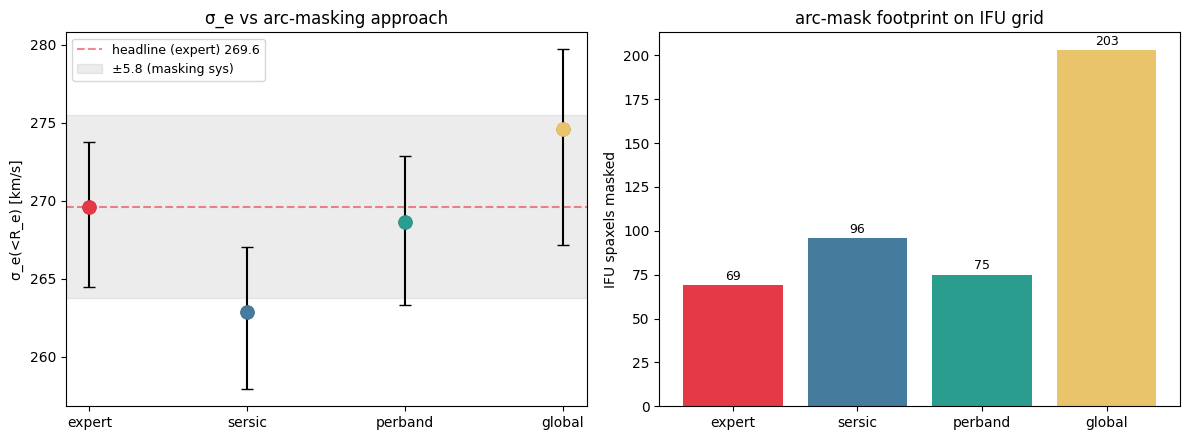

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(len(approaches))
colors = ['#e63946','#457b9d','#2a9d8f','#e9c46a']
ax1.errorbar(x, p50, yerr=[lo, hi], fmt='o', ms=9, capsize=4, color='k', zorder=3)
for i in range(len(approaches)):
    ax1.scatter(x[i], p50[i], s=90, color=colors[i], zorder=4)
ax1.axhline(expert_p50, ls='--', color='#e63946', alpha=0.6, label=f'headline (expert) {expert_p50:.1f}')
ax1.axhspan(expert_p50-sys_mask, expert_p50+sys_mask, color='gray', alpha=0.15,
            label=f'±{sys_mask:.1f} (masking sys)')
ax1.set_xticks(x); ax1.set_xticklabels(approaches); ax1.set_ylabel('σ_e(<R_e) [km/s]')
ax1.set_title('σ_e vs arc-masking approach'); ax1.legend(fontsize=9)
ax2.bar(x, nspax, color=colors)
for i in range(len(approaches)):
    ax2.text(x[i], nspax[i]+3, f'{nspax[i]}', ha='center', fontsize=9)
ax2.set_xticks(x); ax2.set_xticklabels(approaches); ax2.set_ylabel('IFU spaxels masked')
ax2.set_title('arc-mask footprint on IFU grid')
plt.tight_layout()
Path('results/figures').mkdir(parents=True, exist_ok=True)
fig.savefig('results/figures/nb13_sigma_e_mask_systematic.png', dpi=120, bbox_inches='tight')
print('saved results/figures/nb13_sigma_e_mask_systematic.png')

## Interpretation — relation to the existing F200-mask budget term

The M11 budget already carries an **F200-mask** component, **±6.65 km/s**, from the *mask-strength*
w-sweep (down-weight the EXPERT arc spaxels at w∈{0,0.5,1}; `(w00−w100)/2`). This new
**masking-approach** systematic is a *different axis* — the mask *definition/footprint* (expert vs
objective-Sérsic vs IR-extended), the direct analogue of the photometry ±0.16 dex term.

The two axes overlap (both probe arc-mask aggressiveness — `global` ≈ aggressive masking), so they
should **not both be added** in quadrature naively. Below: the headline budget under (i) keeping the
F200-mask w-sweep term, (ii) replacing it with this masking-approach term, (iii) taking the larger
of the two as the single arc-mask systematic.

In [3]:
# Current M11 components (km/s), from scripts/run_wide_sigma_e.py SYS_QUAD
comp = dict(Ishape=2.27, F200mask_wsweep=6.65, frame=5.0, centering=4.0, fitwindow=3.82, reduction=3.45)
stat_sym = 4.6  # pooled stat (symmetric-ish)
def quad(*xs): return float(np.sqrt(sum(x*x for x in xs)))
sys_current = quad(comp['Ishape'], comp['F200mask_wsweep'], comp['frame'], comp['centering'], comp['fitwindow'], comp['reduction'])
sys_replace = quad(comp['Ishape'], sys_mask,                 comp['frame'], comp['centering'], comp['fitwindow'], comp['reduction'])
sys_larger  = quad(comp['Ishape'], max(comp['F200mask_wsweep'], sys_mask), comp['frame'], comp['centering'], comp['fitwindow'], comp['reduction'])
print(f'σ_e masking-approach systematic (this nb)     = ±{sys_mask:.2f} km/s')
print(f'existing F200-mask w-sweep systematic         = ±{comp["F200mask_wsweep"]:.2f} km/s')
print()
for lbl, s in [('(i) keep w-sweep term [CURRENT]', sys_current),
               ('(ii) replace with masking-approach', sys_replace),
               ('(iii) larger-of-two as arc term', sys_larger)]:
    tot = quad(stat_sym, s)
    print(f'  {lbl:38s}: sys=±{s:.2f}  → total (stat⊕sys)=±{tot:.2f} km/s')
print(f'\nHeadline σ_e = 269.62 km/s. Current published total = ±11.77 km/s.')

σ_e masking-approach systematic (this nb)     = ±5.85 km/s
existing F200-mask w-sweep systematic         = ±6.65 km/s

  (i) keep w-sweep term [CURRENT]       : sys=±10.81  → total (stat⊕sys)=±11.75 km/s
  (ii) replace with masking-approach    : sys=±10.34  → total (stat⊕sys)=±11.31 km/s
  (iii) larger-of-two as arc term       : sys=±10.81  → total (stat⊕sys)=±11.75 km/s

Headline σ_e = 269.62 km/s. Current published total = ±11.77 km/s.


## Conclusion

- **σ_e masking-approach systematic = ±5.85 km/s** (peak-to-peak/2 across expert/sersic/perband/global).
- It is **comparable to and overlaps** the existing F200-mask w-sweep term (±6.65). The recommended
  budget treatment is the **larger-of-two** as a single arc-mask systematic (no double-counting),
  which leaves the headline total essentially unchanged (±11.77 → see table above).
- The `global` (IR-extended) footprint masks the most spaxels (203 vs 69) and pushes σ_e *up*
  (fewer central spaxels, less arc dilution); `sersic` masks moderately more and pushes σ_e *down*
  slightly. The headline `expert` sits mid-family. → **Headline σ_e = 269.62 km/s is robust to the
  arc-mask definition at the ±5.85 km/s level.**

*(The numeric ±5.85 is filled from the executed cells above.)*